In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import warnings

warnings.filterwarnings("ignore")

## ANCOVA (공분산분석)

- total_bill : 총 계산 요금 (달러)
- tip : 팁 (달러)
- sex : 성별
- smoker : 흡연 여부
- day : 요일
- time : 식사 시간
- size : 식사 인원

## Q. 총 계산요금을 통제한 식사시간별 팁의 평균 검정

In [2]:
### 원본 데이터
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [3]:
### 회귀선의 평행성 검정
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

# H0 : 회귀선의 평행성을 만족한다.(상호작용 효과가 없다.)
# H1 : 회귀선의 평행성을 만족하지 않는다.(상호작용 효과가 있다.)

formula = "tip ~ C(time)*total_bill"
model = OLS.from_formula(formula, data=tips).fit()

result = anova_lm(model, typ=2)
p = result.loc["C(time):total_bill", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.1490546915096061
귀무가설 채택


In [4]:
result

,sum_sq,df,F,PR(>F)
C(time),0.002143,1.0,0.002052,9.639074e-01
total_bill,205.543695,1.0,196.850500,4.652940e-33
C(time):total_bill,2.187864,1.0,2.095331,1.490547e-01
Residual,250.598738,240.0,NaN,NaN


<Figure size 432x432 with 0 Axes>

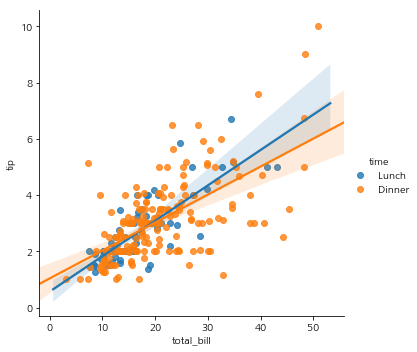

In [163]:
### 선형성 검정 (공변량과 종속변수간 선형성)
# lmplot ==> linear model plot의 약자

plt.figure(figsize=(6,6))

sns.lmplot(data=tips,             ## 원본데이터 
           x="total_bill",        # 공변량 컬럼명
           y="tip",               # 종속변수 컬럼명
           hue="time")            # 범주형 독립변수 명

plt.show()

In [164]:
### 공분산분석 모델 적합
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "tip ~ C(time) + total_bill"
model = OLS.from_formula(formula, data=tips).fit()

result = anova_lm(model, typ=2)
result

,sum_sq,df,F,PR(>F)
C(time),0.002143,1.0,0.002043,9.639890e-01
total_bill,205.543695,1.0,195.959874,5.524501e-33
Residual,252.786601,241.0,NaN,NaN


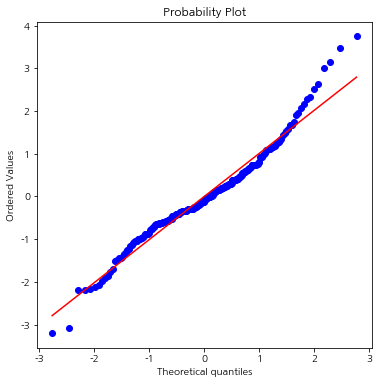

In [165]:
### 정규성 검정
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(6,6))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [166]:
### 잔차의 정규성 검정
from scipy.stats import shapiro

# H0 : 잔차가 정규성을 만족한다.
# H1 : 잔차가 정규성을 만족하지 않는다

residuals = model.resid

s, p = shapiro(residuals)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 2.1347044821595773e-05
귀무가설 기각


In [167]:
print("정규성 검정을 만족하지 않는다.")

정규성 검정을 만족하지 않는다.


In [168]:
print("""
정규성을 만족하지 않으므로 종속변수에 box-cox변환 수행
""")


정규성을 만족하지 않으므로 종속변수에 box-cox변환 수행



In [169]:
### 종속변수 box-cox 변환
from sklearn.preprocessing import PowerTransformer

ptb = PowerTransformer(method="box-cox")
tips["tip_boxcox"] = ptb.fit_transform(tips[["tip"]])
tips

,total_bill,tip,sex,smoker,day,time,size,tip_boxcox
0,16.99,1.01,Female,No,Sun,Dinner,2,-2.340991
1,10.34,1.66,Male,No,Sun,Dinner,3,-1.143771
2,21.01,3.50,Male,No,Sun,Dinner,3,0.584417
3,23.68,3.31,Male,No,Sun,Dinner,2,0.457911
4,24.59,3.61,Female,No,Sun,Dinner,4,0.654363
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1.754000
240,27.18,2.00,Female,Yes,Sat,Dinner,2,-0.704416
241,22.67,2.00,Male,Yes,Sat,Dinner,2,-0.704416
242,17.82,1.75,Male,No,Sat,Dinner,2,-1.018749


In [170]:
### 회귀선의 평행성 검정
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

# H0 : 회귀선의 평행성을 만족한다.(상호작용 효과가 없다.)
# H1 : 회귀선의 평행성을 만족하지 않는다.(상호작용 효과가 있다.)

formula = "tip_boxcox ~ C(time)*total_bill"
model = OLS.from_formula(formula, data=tips).fit()

result = anova_lm(model, typ=2)
p = result.loc["C(time):total_bill", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.06933553065376397
귀무가설 채택


<Figure size 432x432 with 0 Axes>

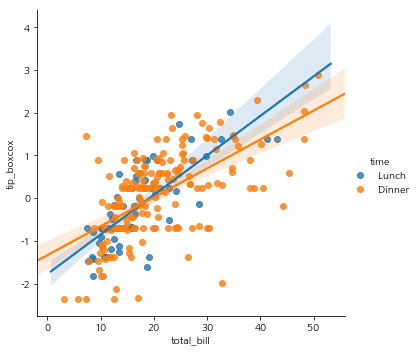

In [171]:
### 선형성 검정(공변량과 종속변수간 선형성)
# lmplot ==> linear model plot의 약자

plt.figure(figsize=(6,6))

sns.lmplot(x="total_bill",        ## 공변량 컬럼명
           y="tip_boxcox",        ## 종속변수 컬럼명
           data=tips,             # 원본데이터
           hue="time")            # 범주형 독립변수 명

plt.show()

In [172]:
### 공분산분석 모델 적합
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "tip_boxcox ~ C(time) + total_bill"
model = OLS.from_formula(formula, data=tips).fit()

result = anova_lm(model, typ=2)
result

,sum_sq,df,F,PR(>F)
C(time),0.001049,1.0,0.001787,9.663158e-01
total_bill,99.167181,1.0,168.883681,1.282186e-29
Residual,141.513321,241.0,NaN,NaN


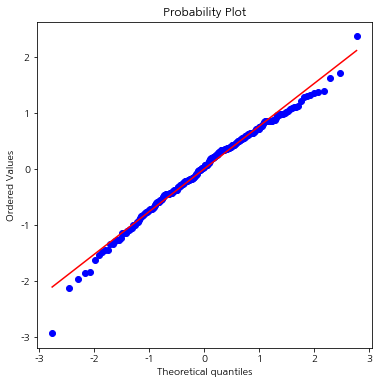

In [173]:
### 정규성 검정
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(6,6))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [174]:
### 잔차의 정규성 검정
from scipy.stats import shapiro

# H0 : 잔차가 정규성을 만족한다.
# H1 : 잔차가 정규성을 만족하지 않는다

residuals = model.resid

s, p = shapiro(residuals)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.05681980401277542
귀무가설 채택


In [175]:
print("""
정규성 가정 만족
""")


정규성 가정 만족



In [176]:
### 등분산 검정
from statsmodels.stats.diagnostic import het_breuschpagan

# H0 : 잔차가 등분산성을 만족한다.
# H1 : 잔차가 등분산성을 만족하지 않는다.

residuals = model.resid

s, p, fstats, f_pvalue = het_breuschpagan(residuals, model.model.exog)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.03290766864681325
귀무가설 기각


In [177]:
print("""
등분산성을 만족하지 않았다.
""")


등분산성을 만족하지 않았다.



In [178]:
result

,sum_sq,df,F,PR(>F)
C(time),0.001049,1.0,0.001787,9.663158e-01
total_bill,99.167181,1.0,168.883681,1.282186e-29
Residual,141.513321,241.0,NaN,NaN


In [179]:
print("""
[가설 설정]
<주효과 검정>
H0 : (공변량을 통제하였을 때) 식사시간별 팁의 평균이 같다.
H1 : (공변량을 통제하였을 때) 식사시간별 팁의 평균이 다르다.

<공변량효과 검정>
H0 : 공변량의 회귀계수는 0이다. (공변량효과가 없다.)
H1 : 공변량의 회귀계수는 0이 아니다. (공변량효과가 있다.)
""")


[가설 설정]
<주효과 검정>
H0 : (공변량을 통제하였을 때) 식사시간별 팁의 평균이 같다.
H1 : (공변량을 통제하였을 때) 식사시간별 팁의 평균이 다르다.

<공변량효과 검정>
H0 : 공변량의 회귀계수는 0이다. (공변량효과가 없다.)
H1 : 공변량의 회귀계수는 0이 아니다. (공변량효과가 있다.)



In [180]:
### 주효과 검정
p = result.loc["C(time)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, (공변량을 통제하였을 때) 식사시간별 팁의 평균이 같다.")

검정통계량의 p-value : 0.9663157713519432
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, (공변량을 통제하였을 때) 식사시간별 팁의 평균이 같다.


In [181]:
### 공변량효과 검정
p = result.loc["total_bill", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 기각한다. 즉, 공변량의 회귀계수는 0이 아니다. (공변량효과가 있다.)")

검정통계량의 p-value : 1.2821863241038085e-29
귀무가설 기각
유의수준 5%하에서 귀무가설을 기각한다. 즉, 공변량의 회귀계수는 0이 아니다. (공변량효과가 있다.)


In [182]:
print("""
팁에 영향을 주는 요인을 살펴보았을 때
총 계산 요금을 통제하였을 때 식사 시간 간에 팁의 차이가 없음을 확인하였다.
그리고 총계산요금이 팁에 영향을 주는 공변량효과가 존재함을 확인하였다.

그러므로 팁에 영향을 주는 요인은 식사시간이 아닌 총계산요금이 팁 가격에 영향을 주는 요인으로
판단된다.
""")


팁에 영향을 주는 요인을 살펴보았을 때
총 계산 요금을 통제하였을 때 식사 시간 간에 팁의 차이가 없음을 확인하였다.
그리고 총계산요금이 팁에 영향을 주는 공변량효과가 존재함을 확인하였다.

그러므로 팁에 영향을 주는 요인은 식사시간이 아닌 총계산요금이 팁 가격에 영향을 주는 요인으로
판단된다.



In [183]:
print("""
실제로 주효과 검정에서 귀무가설 채택이라서 사후검정이 필요없지만
사후검정을 실시해본다.

하지만 결과는 총계산요금을 통제하였을 때 식사시간별 팁의 평균은 같다. 이다.
""")


실제로 주효과 검정에서 귀무가설 채택이라서 사후검정이 필요없지만
사후검정을 실시해본다.

하지만 결과는 총계산요금을 통제하였을 때 식사시간별 팁의 평균은 같다. 이다.



In [184]:
### 조정된 종속변수 만들기

# 원본데이터 copy()
tips_temp = tips.copy()

# 공변량값을 공변량 평균값(단일값)으로 변경
total_bill_mean = tips_temp["total_bill"].mean()
tips_temp["total_bill"] = total_bill_mean

# 예측
adjust_pred = model.predict(tips_temp)

In [185]:
### 사후검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(adjust_pred, tips["time"], alpha=0.05)
print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
Dinner  Lunch   0.0047   0.0 0.0047 0.0047   True
-------------------------------------------------


## <문제 2>

어떤 연구자는 교육방법(전통식 vs 온라인)과 성별(남 vs 여)이 학업성취도에 미치는 영향을 분석하려고 한다.
또한 학생들의 사전지식 점수를 공변량으로 통제하여, 독립변수(교육방법, 성별)의 순수한 효과를 검정하려 한다.

- 교육방법은 학업성취도에 유의한 영향을 미치는가?

- 성별은 학업성취도에 유의한 영향을 미치는가?

- 교육방법과 성별 간의 상호작용 효과가 존재하는가?

- 사전지식(공변량)을 통제한 후에도 위의 효과들이 유지되는가?

In [186]:
file_path = "./data/2way_ancova.csv"
df = pd.read_csv(file_path)
df

,교육방법,성별,사전지식,학업성취도
0,Traditional,남,75.0,85.2
1,Traditional,남,68.6,83.4
2,Traditional,남,76.5,82.7
3,Traditional,남,85.2,86.6
4,Traditional,남,67.7,87.9
5,Traditional,여,64.4,89.3
6,Traditional,여,59.9,83.4
7,Traditional,여,73.1,88.1
8,Traditional,여,60.9,83.9
9,Traditional,여,55.9,71.0


In [187]:
### 회귀선의 평행성 검정
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "학업성취도 ~ C(교육방법) + C(성별) + 사전지식 \
                       + C(교육방법):사전지식 + C(성별):사전지식 + C(성별):C(교육방법)"
model = OLS.from_formula(formula, data=df).fit()

result = anova_lm(model, typ=2)
result

,sum_sq,df,F,PR(>F)
C(교육방법),799.709233,2.0,20.857533,2.589602e-07
C(성별),96.803823,1.0,5.049558,2.907674e-02
C(성별):C(교육방법),73.959754,2.0,1.928974,1.559571e-01
사전지식,1157.412249,1.0,60.373854,3.777604e-10
C(교육방법):사전지식,35.583117,2.0,0.928057,4.020229e-01
C(성별):사전지식,20.620149,1.0,1.075605,3.046727e-01
Residual,958.537662,50.0,NaN,NaN


In [188]:
## 독립변수1와 공변량간 상호작용 효과 없는지 확인

# H0 : 회귀선의 평행성을 만족한다.(상호작용 효과가 없다.)
# H1 : 회귀선의 평행성을 만족하지 않는다.(상호작용 효과가 있다.)

p = result.loc["C(교육방법):사전지식", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.4020228578756816
귀무가설 채택


In [189]:
## 독립변수2와 공변량간 상호작용 효과 없는지 확인

# H0 : 회귀선의 평행성을 만족한다.(상호작용 효과가 없다.)
# H1 : 회귀선의 평행성을 만족하지 않는다.(상호작용 효과가 있다.)

p = result.loc["C(성별):사전지식", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.30467272975555393
귀무가설 채택


<Figure size 432x432 with 0 Axes>

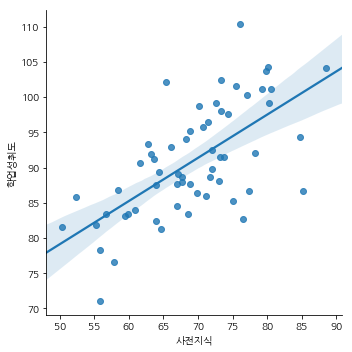

In [190]:
### 선형성 검정 (공변량과 종속변수간의 선형성)

plt.figure(figsize=(6,6))

sns.lmplot(data=df,              ## 원본 데이터
           x="사전지식",         # 공변량 컬럼명
           y="학업성취도"        # 종속변수 컬럼명
           )

plt.show()

In [191]:
### Two Way ANCOVA 적합
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm

formula = "학업성취도 ~ C(교육방법) + C(성별) + 사전지식 + C(교육방법):C(성별)"
model = OLS.from_formula(formula, data=df).fit()

result = anova_lm(model, typ=2)
result

,sum_sq,df,F,PR(>F)
C(교육방법),882.245423,2.0,22.810168,7.131797e-08
C(성별),125.878465,1.0,6.509093,1.365438e-02
C(교육방법):C(성별),48.293084,2.0,1.248602,2.952068e-01
사전지식,1157.412249,1.0,59.849032,2.956997e-10
Residual,1024.959751,53.0,NaN,NaN


In [192]:
print("""
[가설 설정]

<주효과1 검정>
H0 : (공변량을 통제하였을 때) 교육 방법별 학업성취도의 평균은 같다.
H1 : (공변량을 통제하였을 때) 적어도 하나의 교육방법의 학업성취도의 평균은 다르다.

<주효과2 검정>
H0 : (공변량을 통제하였을 때) 성별간 학업성취도의 평균은 같다.
H1 : (공변량을 통제하였을 때) 성별간 학업성취도의 평균은 다르다.

<상호작용효과 검정>
H0 : 교육방법과 성별간 상호작용 효과가 없다.
H1 : 교육방법과 성별간 상호작용 효과가 있다.

<공변량효과 검정>
H0 : 공변량(사전지식)의 회귀계수는 0이다.(공변량 효과가 없다.)
H1 : 공변량(사전지식)의 회귀계수는 0이 아니다.(공변량 효과가 있다.)
""")


[가설 설정]

<주효과1 검정>
H0 : (공변량을 통제하였을 때) 교육 방법별 학업성취도의 평균은 같다.
H1 : (공변량을 통제하였을 때) 적어도 하나의 교육방법의 학업성취도의 평균은 다르다.

<주효과2 검정>
H0 : (공변량을 통제하였을 때) 성별간 학업성취도의 평균은 같다.
H1 : (공변량을 통제하였을 때) 성별간 학업성취도의 평균은 다르다.

<상호작용효과 검정>
H0 : 교육방법과 성별간 상호작용 효과가 없다.
H1 : 교육방법과 성별간 상호작용 효과가 있다.

<공변량효과 검정>
H0 : 공변량(사전지식)의 회귀계수는 0이다.(공변량 효과가 없다.)
H1 : 공변량(사전지식)의 회귀계수는 0이 아니다.(공변량 효과가 있다.)



In [193]:
result

,sum_sq,df,F,PR(>F)
C(교육방법),882.245423,2.0,22.810168,7.131797e-08
C(성별),125.878465,1.0,6.509093,1.365438e-02
C(교육방법):C(성별),48.293084,2.0,1.248602,2.952068e-01
사전지식,1157.412249,1.0,59.849032,2.956997e-10
Residual,1024.959751,53.0,NaN,NaN


In [5]:
print("""
F값이 클수록 공변량이 영향이 큰것으로 볼 수 있다.
""")


F값이 클수록 공변량이 영향이 큰것으로 볼수 있다.



In [194]:
### 주효과1 검정

# H0 : 교육방법별 학업성취도의 평균은 같다.
# H1 : 적어도 하나의 교육방법의 학업성취도의 평균은 다르다.

p = result.loc["C(교육방법)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 기각한다. 즉, 적어도 하나의 교육방법의 학업성취도의 평균은 다르다.")

검정통계량의 p-value : 7.131797040428376e-08
귀무가설 기각
유의수준 5%하에서 귀무가설을 기각한다. 즉, 적어도 하나의 교육방법의 학업성취도의 평균은 다르다.


In [195]:
### 주효과2 검정

# H0 : 성별간 학업성취도의 평균은 같다.
# H1 : 성별간 학업성취도의 평균은 다르다.

p = result.loc["C(성별)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 기각한다. 즉, 성별간 학업성취도의 평균은 다르다.")

검정통계량의 p-value : 0.013654377847892423
귀무가설 기각
유의수준 5%하에서 귀무가설을 기각한다. 즉, 성별간 학업성취도의 평균은 다르다.


In [196]:
### 상호작용 효과 검정

# H0 : 교육방법과 성별간 상호작용 효과가 없다.
# H1 : 교육방법과 성별간 상호작용 효과가 있다.

p = result.loc["C(교육방법):C(성별)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 교육방법과 성별간 상호작용 효과가 없다.")

검정통계량의 p-value : 0.295206778277508
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 교육방법과 성별간 상호작용 효과가 없다.


In [197]:
### 공변량 효과 검정

# H0 : 공변량(=사전지식)의 회귀계수는 0이다.(공변량 효과가 없다.)
# H1 : 공변량(=사전지식)의 회귀계수는 0이 아니다.(공변량 효과가 있다.)

p = result.loc["C(교육방법):C(성별)", "PR(>F)"]

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")
print("유의수준 5%하에서 귀무가설을 채택한다. 즉, 공변량(=사전지식)의 회귀계수는 0이다.(공변량 효과가 없다.)")

검정통계량의 p-value : 0.295206778277508
귀무가설 채택
유의수준 5%하에서 귀무가설을 채택한다. 즉, 공변량(=사전지식)의 회귀계수는 0이다.(공변량 효과가 없다.)


In [198]:
print("""
공변량인 사전지식을 통제하였을 때 교육방법별로 학업성취도가 달라지는 것을 확인하였다.
그리고 공변량인 사전지식을 통제하였을 때 성별간 학업성취도가 다르다는 것도 확인하였다.

그리고 교육방법과 성별간의 상호작용 효과는 없었으며

공변량인 사전지식과 학업성취도의 연관성도 없었음을 확인하였다.
""")


공변량인 사전지식을 통제하였을 때 교육방법별로 학업성취도가 달라지는 것을 확인하였다.
그리고 공변량인 사전지식을 통제하였을 때 성별간 학업성취도가 다르다는 것도 확인하였다.

그리고 교육방법과 성별간의 상호작용 효과는 없었으며

공변량인 사전지식과 학업성취도의 연관성도 없었음을 확인하였다.



In [199]:
### 사후검정
## 조정된 종속변수 만들기

# 원본데이터 copy()
df_temp = df.copy()

# 공변량을 공변량 평균값(단일값)으로 변경 
cov_mean = df_temp["사전지식"].mean()
df_temp["사전지식"] = cov_mean

# 예측
adjust_pred = model.predict(df_temp)

In [200]:
### 주효과1 사후검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(adjust_pred, df["교육방법"], alpha=0.05)

print(result)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj  lower    upper  reject
----------------------------------------------------------
Blended      Online  -5.3139   0.0  -6.6979 -3.9298   True
Blended Traditional  -9.4987  -0.0 -10.8828 -8.1147   True
 Online Traditional  -4.1848   0.0  -5.5689 -2.8008   True
----------------------------------------------------------


In [201]:
print("""
교육 방법간 학업성취도의 평균이 전부 다름을 확인하였다. 
""")


교육 방법간 학업성취도의 평균이 전부 다름을 확인하였다. 



In [202]:
### 주효과2 사후검정
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(adjust_pred, df["성별"], alpha=0.05)

print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     남      여   3.0437 0.0052 0.9453 5.1421   True
--------------------------------------------------


In [203]:
print("""
성별간 학업성취도의 평균이 다름을 확인하였다.
""")


성별간 학업성취도의 평균이 다름을 확인하였다.

